In [119]:
import numpy as np
import pandas as pd
import stan
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genextreme
import arviz as az
import nest_asyncio
import asyncio
nest_asyncio.apply()


# 0. Definición de funciones

In [120]:
def plot_station_timeseries(data, figsize=(20, 20)):
    """
    Crea scatter plots de las series temporales de precipitación máxima por estación.
    """
    # Número de estaciones
    n_stations = len(data.columns)
    
    # Calcular layout óptimo para los subplots
    n_rows = int(np.ceil(n_stations/2))  # 2 columnas
    
    # Crear figura
    fig, axs = plt.subplots(n_rows, 2, figsize=figsize)
    if n_rows == 1:
        axs = axs.reshape(1, -1)
    
    # Convertir índice a años numéricos para los cálculos
    years = pd.to_datetime(data.index).year
    
    # Plotear cada estación
    for idx, station in enumerate(data.columns):
        row = idx // 2
        col = idx % 2
        
        ax = axs[row, col]
        
        # Obtener datos no faltantes y sus años correspondientes
        station_data = data[station].dropna()
        valid_mask = ~data[station].isna()
        valid_years = years[valid_mask]
        
        # Scatter plot de los datos
        ax.scatter(valid_years, station_data, 
                  color='blue', 
                  alpha=0.6,
                  label='Observaciones')
        
        if len(station_data) > 1:  # Si hay al menos 2 puntos para la tendencia
            # Línea de tendencia usando años numéricos
            z = np.polyfit(valid_years, station_data, 1)
            p = np.poly1d(z)
            
            # Crear años continuos para la línea de tendencia
            trend_years = np.linspace(valid_years.min(), valid_years.max(), 100)
            ax.plot(trend_years, p(trend_years), "r--", 
                   alpha=0.8, label=f'Tendencia ({z[0]:.2f} mm/año)')
        
        # Estadísticas básicas
        mean_val = station_data.mean()
        std_val = station_data.std()
        
        # Líneas de media y ±2std
        ax.axhline(y=mean_val, color='g', linestyle='--', alpha=0.5, label='Media')
        ax.axhline(y=mean_val + 2*std_val, color='g', linestyle=':', alpha=0.3)
        ax.axhline(y=mean_val - 2*std_val, color='g', linestyle=':', alpha=0.3)
        
        # Personalizar plot
        ax.set_title(f'Estación {station}')
        ax.set_xlabel('Años')
        ax.set_ylabel('Pmax (mm)')
        
        # Ajustar eje x específico para esta estación
        ax.set_xticks(valid_years[::2])  # Mostrar cada segundo año
        ax.set_xticklabels(valid_years[::2], rotation=90)
        
        ax.grid(True, alpha=0.3)
        
        # Añadir texto con estadísticas
        stats_text = (f'N datos: {len(station_data)}\n'
                     f'Período: {min(valid_years)}-{max(valid_years)}\n'
                     f'Media: {mean_val:.1f} mm\n'
                     f'Std: {std_val:.1f} mm\n'
                     f'CV: {std_val/mean_val:.2f}\n'
                     f'Máx: {station_data.max():.1f} mm\n'
                     f'Mín: {station_data.min():.1f} mm')
        
        ax.text(0.02, 0.98, stats_text,
                transform=ax.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Leyenda
        if idx == 0:  # Solo para el primer plot
            ax.legend(bbox_to_anchor=(0.5, 1), loc='upper left')
    
    plt.suptitle('Series Temporales de Precipitación Máxima por Estación', y=1.02, fontsize=14)
    plt.tight_layout()
    
    # Calcular estadísticas adicionales
    stats = []
    for station in data.columns:
        station_data = data[station].dropna()
        valid_mask = ~data[station].isna()
        valid_years = years[valid_mask]
        if len(station_data) > 1:
            trend = np.polyfit(valid_years, station_data, 1)[0]
        else:
            trend = np.nan
            
        stats.append({
            'Estación': station,
            'N datos': len(station_data),
            'Período': f"{min(valid_years)}-{max(valid_years)}",
            'Media (mm)': station_data.mean(),
            'Std (mm)': station_data.std(),
            'CV': station_data.std() / station_data.mean(),
            'Máximo (mm)': station_data.max(),
            'Mínimo (mm)': station_data.min(),
            'Tendencia (mm/año)': trend
        })
    
    stats_df = pd.DataFrame(stats).round(3)
    
    return fig, stats_df


## 0.1 Modelos jerárquicos stan

In [121]:
# Modelo Stan (igual que antes)
hierarchical_gev_model = """
// Bloque de datos: especifica los datos que entran al modelo
data {
    int<lower=0> N_stations;     // Número de estaciones
    int<lower=0> N_years;        // Número de años por estación
    matrix[N_years, N_stations] y;  // Matriz de datos: filas=años, columnas=estaciones
    real y_mean;                 // Media global de los datos para prior informativo
    real y_sd;                   // Desviación estándar global para prior informativo
}

// Bloque de parámetros: define los parámetros a estimar
parameters {
    // Parámetros a nivel población
    real mu_pop;                    // Ubicación poblacional
    real<lower=0> sigma_pop;        // Escala poblacional (debe ser positiva)
    real<lower=-1,upper=1> xi_pop;  // Forma poblacional (restringida entre -1 y 1)
    
    // Parámetros "raw" para parametrización no centrada
    vector[N_stations] mu_raw;      // Desviaciones raw para ubicación
    vector[N_stations] sigma_raw;    // Desviaciones raw para escala
    vector[N_stations] xi_raw;       // Desviaciones raw para forma
    
    // Parámetros de variabilidad entre estaciones
    real<lower=0> tau_mu;           // Cuánto puede variar la ubicación entre estaciones
    real<lower=0> tau_sigma;        // Cuánto puede variar la escala
    real<lower=0> tau_xi;           // Cuánto puede variar la forma
}

// Bloque de parámetros transformados: cálculos determinísticos
transformed parameters {
    // Parámetros específicos por estación
    vector[N_stations] mu_station;     // Ubicación por estación
    vector<lower=0>[N_stations] sigma_station;  // Escala por estación (positiva)
    vector<lower=-1,upper=1>[N_stations] xi_station;  // Forma por estación (restringida)
    
    // Parametrización no centrada: transforma parámetros raw en parámetros de estación
    mu_station = mu_pop + tau_mu * mu_raw;        // Transformación lineal
    sigma_station = sigma_pop * exp(tau_sigma * sigma_raw);  // Transformación log-lineal
    xi_station = xi_pop + tau_xi * xi_raw;        // Transformación lineal
}

// Bloque del modelo: define priors y likelihood
model {
    // Priors para parámetros poblacionales
    mu_pop ~ normal(y_mean, y_sd);        // Prior informativo basado en los datos
    sigma_pop ~ lognormal(log(y_sd), 1); // Prior log-normal para escala
    xi_pop ~ normal(0, 6);                // Prior para forma, permite valores positivos y negativos
    
    // Priors para parámetros raw (distribución estándar normal)
    mu_raw ~ normal(0, 50);      // Prior estándar para desviaciones de ubicación
    sigma_raw ~ normal(0, 12);    // Prior estándar para desviaciones de escala
    xi_raw ~ normal(0, 6);       // Prior estándar para desviaciones de forma
    
    // Priors para parámetros de variabilidad (exponencial para positividad)
    tau_mu ~ exponential(1);     // Prior exponencial para variabilidad de ubicación
    tau_sigma ~ exponential(2);   // Prior exponencial para variabilidad de escala
    tau_xi ~ exponential(4);      // Prior exponencial para variabilidad de forma
    
    // Likelihood
    for (s in 1:N_stations) {     // Loop sobre estaciones
        for (n in 1:N_years) {    // Loop sobre años
            if (is_nan(y[n,s])) continue;  // Salta valores faltantes
            
            // Likelihood GEV
            if (abs(xi_station[s]) > 1e-6) {  // Caso xi ≠ 0
                real z = (y[n,s] - mu_station[s]) / sigma_station[s];
                if (1 + xi_station[s] * z > 0) {  // Condición de soporte
                    target += -log(sigma_station[s]) 
                             - (1 + 1/xi_station[s]) * log1p(xi_station[s] * z)
                             - pow(1 + xi_station[s] * z, -1/xi_station[s]);
                } else {
                    target += negative_infinity();  // Fuera del soporte
                }
            } else {  // Caso xi ≈ 0 (Gumbel)
                real z = (y[n,s] - mu_station[s]) / sigma_station[s];
                target += -log(sigma_station[s]) - z - exp(-z);
            }
        }
    }
}

generated quantities {
    matrix[N_stations, 4] return_levels;
    array[4] int return_periods = {2, 10, 50, 100};
    
    for (s in 1:N_stations) {
        for (r in 1:4) {
            real p = 1 - 1.0/return_periods[r];
            if (abs(xi_station[s]) > 1e-6) {
                return_levels[s,r] = mu_station[s] + (sigma_station[s]/xi_station[s]) * 
                                   (pow(-log(p), -xi_station[s]) - 1);
            } else {
                return_levels[s,r] = mu_station[s] - sigma_station[s] * log(-log(p));
            }
        }
    }
}
"""

In [122]:
def fit_gev_hierarchical(data):
    """
    Ajusta el modelo GEV jerárquico a los datos con inicialización robusta.
    """
    # Preparar datos
    data_dict = {
        'N_stations': len(data.columns),
        'N_years': len(data),
        'y': data.values,
        'y_mean': np.nanmean(data.values),
        'y_sd': np.nanstd(data.values)
    }
    
    # Generar valores iniciales razonables
    def init_fn():
        init_dict = {
            'mu_pop': float(np.nanmean(data.values)),
            'sigma_pop': float(np.nanstd(data.values)),
            'xi_pop': 0.1,
            'mu_raw': np.random.normal(0, 0.1, size=len(data.columns)).tolist(),
            'sigma_raw': np.random.normal(0, 0.1, size=len(data.columns)).tolist(),
            'xi_raw': np.random.normal(0, 0.1, size=len(data.columns)).tolist(),
            'tau_mu': 1.0,
            'tau_sigma': 0.5,
            'tau_xi': 0.25
        }
        return init_dict
    
    # Lista de diccionarios de inicialización para cada cadena
    init_list = [init_fn() for _ in range(4)]
    
    # Compilar y ajustar modelo
    posterior = stan.build(
                hierarchical_gev_model,  # Tu código del modelo en lenguaje Stan
                data=data_dict,
                random_seed=42)  # opcional pero recomendable para reproducibilidad)

    fit = posterior.sample(
        num_chains=4,
        num_samples=4000,  # Iteraciones después del warmup
        num_warmup=2000,
        init=init_list)  # Aquí también puedes pasar lista de diccionarios para inicialización)       

    
    return fit


Funciones para el análisis comparativo

In [123]:
def plot_population_parameters_comparison(samples, samples_, title="Comparación de Parámetros Poblacionales"):
    # Preparar datos
    params = ['mu_pop', 'sigma_pop', 'xi_pop']
    data_with = [samples[p] for p in params]
    data_without = [samples_[p] for p in params]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for i, (param, ax) in enumerate(zip(params, axes)):
        sns.kdeplot(data_with[i], ax=ax, label='Con DANA', color='red', alpha=0.6)
        sns.kdeplot(data_without[i], ax=ax, label='Sin DANA', color='blue', alpha=0.6)
        ax.set_title(f'Distribución de {param}')
        ax.legend()
    
    plt.tight_layout()
    
    return fig


In [124]:
import numpy as np
import matplotlib.pyplot as plt

def plot_return_levels_comparison(samples_df1, samples_df2, stations, return_period_idx=4):
    """
    Compara los niveles de retorno entre dos conjuntos de muestras.

    Parameters:
    - samples_df1: DataFrame de muestras del primer ajuste (con DANA).
    - samples_df2: DataFrame del segundo ajuste (sin DANA).
    - stations: lista con los nombres de las estaciones.
    - return_period_idx: índice del periodo de retorno (Stan indexa desde 1, por defecto 4 → T=100 años).
    """

    n_stations = len(stations)

    # Reconstruir el array de niveles de retorno
    levels_with = np.stack(
        [samples_df1[f'return_levels.{i+1}.{return_period_idx}'].values for i in range(n_stations)],
        axis=1
    )
    levels_without = np.stack(
        [samples_df2[f'return_levels.{i+1}.{return_period_idx}'].values for i in range(n_stations)],
        axis=1
    )

    means_with = np.mean(levels_with, axis=0)
    ci_with = np.percentile(levels_with, [2.5, 97.5], axis=0)

    means_without = np.mean(levels_without, axis=0)
    ci_without = np.percentile(levels_without, [2.5, 97.5], axis=0)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(n_stations)

    ax.errorbar(
        x - 0.2, means_with,
        yerr=[means_with - ci_with[0], ci_with[1] - means_with],
        fmt='o', label='Con DANA', capsize=5, color='red', alpha=0.7
    )
    ax.errorbar(
        x + 0.2, means_without,
        yerr=[means_without - ci_without[0], ci_without[1] - means_without],
        fmt='o', label='Sin DANA', capsize=5, color='blue', alpha=0.7
    )

    ax.set_xticks(x)
    ax.set_xticklabels(stations, rotation=45)
    ax.set_title(f'Niveles de Retorno T=100 años (índice {return_period_idx})')
    ax.set_ylabel('Nivel de Retorno')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


In [125]:
def plot_uncertainty_comparison(samples, samples_, stations):
    # Primero, imprimir las formas de los arrays originales
    print("Forma de return_levels con DANA:", samples['return_levels'].shape)
    print("Forma de return_levels sin DANA:", samples_['return_levels'].shape)
    print("Número de estaciones:", len(stations))
    
    try:
        # Calcular intervalos de credibilidad para T=100 años
        ci_with = np.percentile(samples['return_levels'][:, :, 3], [2.5, 97.5], axis=0)
        ci_without = np.percentile(samples_['return_levels'][:, :, 3], [2.5, 97.5], axis=0)
        
        print("Forma de ci_with:", ci_with.shape)
        print("Forma de ci_without:", ci_without.shape)
        
        # Calcular rangos
        ci_ranges_with = ci_with[1] - ci_with[0]
        ci_ranges_without = ci_without[1] - ci_without[0]
        
        print("Forma de ci_ranges_with:", ci_ranges_with.shape)
        print("Forma de ci_ranges_without:", ci_ranges_without.shape)
        
        # Crear el gráfico
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(stations))
        width = 0.35
        
        # Asegurarse de que los arrays son unidimensionales
        ci_ranges_with = np.array(ci_ranges_with).flatten()
        ci_ranges_without = np.array(ci_ranges_without).flatten()
        
        ax.bar(x - width/2, ci_ranges_with, width, label='Con DANA', color='red', alpha=0.6)
        ax.bar(x + width/2, ci_ranges_without, width, label='Sin DANA', color='blue', alpha=0.6)
        
        ax.set_xticks(x)
        ax.set_xticklabels(stations, rotation=45)
        ax.set_title('Amplitud de Intervalos de Credibilidad (T=100 años)')
        ax.set_ylabel('Amplitud del Intervalo')
        ax.legend()
        
        plt.tight_layout()
        return fig
    
    except Exception as e:
        print(f"Error durante la ejecución: {str(e)}")
        raise


# 1. Análisis exploratorio de datos

In [126]:
Path = 'data/'


In [127]:
# Importa dataset desde CSV con primera columna como índice de fechas
ALL_MAX = pd.read_csv(Path + 'Daily_series_conjuntas_V2.csv', index_col=0, parse_dates=True)

# Extrae subset de 9 estaciones específicas
Station_filter = ALL_MAX

# Filtra dataset para incluir solo registros desde 2000
Station_filter = Station_filter.loc['2000':,:]

# Agrega datos a nivel anual calculando sumas
Station_filter = Station_filter.resample('YE').max()

# Sustituye valores cero por NaN para manejo adecuado de datos faltantes
Station_filter = Station_filter.replace(0.0, np.nan)

Station_filter.head()


,V05,V23,V01,V103,V10,CS08,CS101,CS01,V19,V20,...,c31m048e08,c06m901e02,c31m031e06,c16m021e02,c07m114e01,c26m003e04,c30m082e11,c26m084e01,c24m090e01,c29m105e02
2000-12-31,201.4,NaN,268.0,69.4,147.4,NaN,97.9,105.8,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-12-31,51.6,46.0,34.0,70.5,47.8,26.2,43.1,49.6,60.0,92.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-12-31,101.8,333.6,68.4,83.8,66.0,77.2,50.1,82.6,98.6,55.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2003-12-31,57.8,129.0,66.0,59.0,69.2,110.0,75.0,79.8,56.2,70.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-12-31,83.0,90.0,49.4,98.8,138.4,165.2,101.7,124.8,57.6,79.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Modelo Jerárquico

Se ejecutarán dos versiones del modelo jerárquico para comparar resultados: una incorporando los datos del evento DANA de Valencia 2024, y otra excluyendo estos registros. En ambos casos, se analizarán tanto los parámetros poblacionales como los específicos de cada distribución local, con especial énfasis en la evaluación del evento de 100 años de periodo de retorno. Esta estrategia permitirá evaluar la sensibilidad del modelo a eventos extremos recientes, cuantificar su impacto en la estructura jerárquica completa y valorar cómo la inclusión o exclusión de eventos extremos altera las estimaciones de eventos con baja probabilidad de ocurrencia.

In [128]:
Station_filter.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25 entries, 2000-12-31 to 2024-12-31
Freq: YE-DEC
Columns: 224 entries, V05 to c29m105e02
dtypes: float64(224)
memory usage: 43.9 KB


## 2.1. Con evento **DANA**

In [129]:
# Asegurarse que los datos son float
Station_filter_copy = Station_filter.astype(float)

# Ajustar modelo
fit_all = fit_gev_hierarchical(Station_filter_copy)

# Extraer resultados
samples = fit_all.to_frame()

# Imprimir parámetros poblacionales
print("\nParámetros poblacionales (media ± desv. std):")
print(f"μ población: {np.mean(samples['mu_pop']):.2f} ± {np.std(samples['mu_pop']):.2f}")
print(f"σ población: {np.mean(samples['sigma_pop']):.2f} ± {np.std(samples['sigma_pop']):.2f}")
print(f"ξ población: {np.mean(samples['xi_pop']):.3f} ± {np.std(samples['xi_pop']):.3f}")

# Imprimir niveles de retorno para T=100 años (4º periodo)
print("\nNiveles de retorno para T=100 años:")
for i, station in enumerate(Station_filter_copy.columns):
    col_name = f'return_levels.{i+1}.4'  # Correcto según el nombre de las columnas
    levels = samples[col_name]
    mean = np.mean(levels)
    ci = np.percentile(levels, [2.5, 97.5])
    print(f"{station}: {mean:.1f} [{ci[0]:.1f}, {ci[1]:.1f}]")


Building...



Building: found in cache, done.

Messages from stanc:
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 67, column 16: A
    control flow statement depends on parameter(s): mu_pop, mu_raw,
    sigma_pop, sigma_raw, tau_mu, tau_sigma, tau_xi, xi_pop, xi_raw.
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 65, column 12: A
    control flow statement depends on parameter(s): tau_xi, xi_pop, xi_raw.
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 51, column 26: Argument
    12 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 50, column 23: Argument
    50 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In 


Parámetros poblacionales (media ± desv. std):
μ población: 56.24 ± 1.07
σ población: 27.21 ± 0.69
ξ población: 0.174 ± 0.016

Niveles de retorno para T=100 años:
V05: 219.4 [160.4, 304.9]
V23: 315.9 [236.7, 430.1]
V01: 246.0 [179.0, 345.4]
V103: 265.0 [198.6, 359.4]
V10: 218.2 [161.6, 298.6]
CS08: 249.2 [183.9, 343.0]
CS101: 235.5 [173.1, 321.9]
CS01: 240.3 [178.7, 324.3]
V19: 253.4 [187.4, 342.2]
V20: 202.1 [149.4, 273.0]
V02: 178.4 [128.3, 244.2]
V104: 257.4 [190.5, 341.5]
A05: 304.4 [230.9, 416.5]
CS07: 230.5 [170.1, 313.7]
CS06: 246.0 [181.3, 334.4]
V22: 318.2 [242.0, 428.5]
c30m136e03: 494.0 [370.5, 676.2]
A101: 169.3 [120.5, 238.4]
CS03: 230.1 [175.9, 304.9]
A03: 160.7 [114.8, 225.7]
8050X: 278.1 [208.8, 374.6]
V102: 348.8 [264.1, 464.4]
CS09: 188.5 [138.2, 259.5]
V101: 217.0 [158.4, 295.0]
A08: 182.3 [129.4, 251.5]
CS05: 226.6 [166.6, 310.0]
c11m116e05: 192.6 [142.0, 264.6]
V07: 303.3 [226.4, 408.2]
A15: 251.1 [184.7, 343.6]
A04: 314.1 [241.9, 414.2]
V04: 254.9 [188.7, 344.5]
A

In [130]:
samples_df = fit_all.to_frame()

mu_station_1 = samples_df['mu_station.1']
sigma_station_1 = samples_df['sigma_station.1']
xi_station_1 = samples_df['xi_station.1']

print(f"Media de μ estación 1: {mu_station_1.mean():.2f} ± {mu_station_1.std():.2f}")
print(f"Media de σ estación 1: {sigma_station_1.mean():.2f} ± {sigma_station_1.std():.2f}")
print(f"Media de ξ estación 1: {xi_station_1.mean():.3f} ± {xi_station_1.std():.3f}")


Media de μ estación 1: 49.82 ± 4.57
Media de σ estación 1: 23.34 ± 3.99
Media de ξ estación 1: 0.183 ± 0.045


Aquí visualizamos la distribución del evento de 100 años de periodo de retorno derivada directamente de los parámetros poblacionales del modelo jerárquico. Este gráfico representa una visión regional del riesgo, mostrando la distribución de probabilidad del evento centenario según las características comunes identificadas por el modelo para toda la zona de estudio. La media y los intervalos de credibilidad del 95% nos permiten cuantificar no solo la magnitud esperada de estos eventos extremos a nivel regional, sino también la incertidumbre asociada a esta estimación considerando la información del evento DANA 2024.


Estadísticas del período de retorno de 100 años (parámetros poblacionales):
Media: 248.21
Intervalo de credibilidad 95%: [231.71, 266.10]


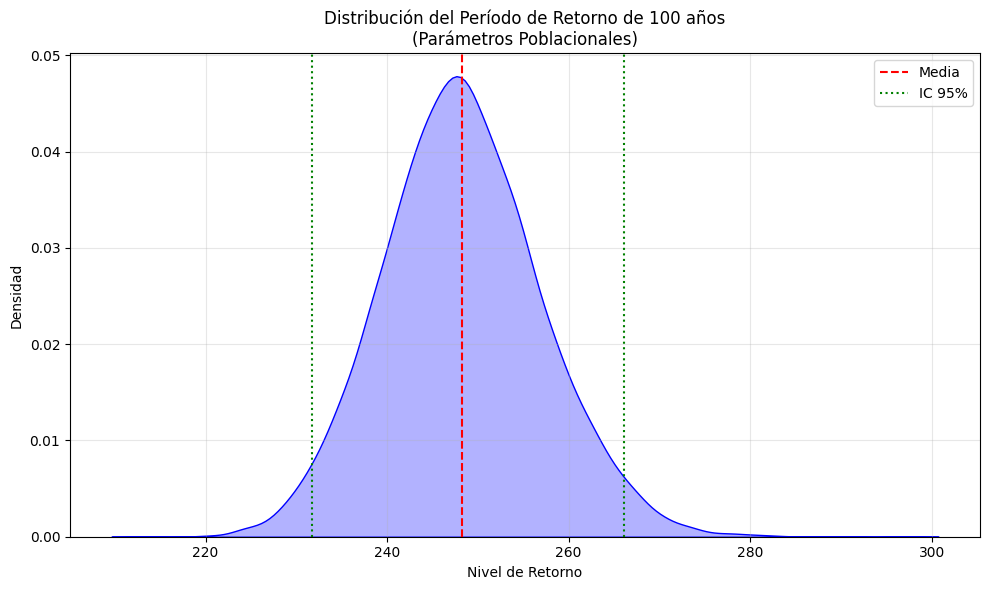

In [131]:
# Extraer los parámetros poblacionales de las muestras MCMC
mu_pop_samples = samples['mu_pop']
sigma_pop_samples = samples['sigma_pop']
xi_pop_samples = samples['xi_pop']

# Función para calcular el nivel de retorno de 100 años
def return_level_100(mu, sigma, xi):
    p = 1 - 1/100  # probabilidad para T=100
    if abs(xi) > 1e-6:
        return mu + (sigma/xi) * (np.power(-np.log(p), -xi) - 1)
    else:
        return mu - sigma * np.log(-np.log(p))

# Calcular niveles de retorno para cada muestra MCMC
n_samples = len(mu_pop_samples)
return_levels_100 = np.zeros(n_samples)

for i in range(n_samples):
    return_levels_100[i] = return_level_100(
        mu_pop_samples[i], 
        sigma_pop_samples[i], 
        xi_pop_samples[i]
    )

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Graficar KDE de los niveles de retorno
sns.kdeplot(data=return_levels_100, color='blue', fill=True, alpha=0.3)

# Añadir línea vertical con la media
mean_level = np.mean(return_levels_100)
ci_lower, ci_upper = np.percentile(return_levels_100, [2.5, 97.5])

plt.axvline(mean_level, color='red', linestyle='--', label='Media')
plt.axvline(ci_lower, color='green', linestyle=':', label='IC 95%')
plt.axvline(ci_upper, color='green', linestyle=':')

# Personalizar el gráfico
plt.title('Distribución del Período de Retorno de 100 años\n(Parámetros Poblacionales)')
plt.xlabel('Nivel de Retorno')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)

# Imprimir estadísticas
print(f"\nEstadísticas del período de retorno de 100 años (parámetros poblacionales):")
print(f"Media: {mean_level:.2f}")
print(f"Intervalo de credibilidad 95%: [{ci_lower:.2f}, {ci_upper:.2f}]")

plt.tight_layout();


Para comprender mejor las estimaciones de riesgo hidrológico, visualizamos las distribuciones de probabilidad del evento de 100 años de periodo de retorno para cada estación. Estos gráficos nos muestran tanto los valores medios esperados como la incertidumbre asociada (intervalos de confianza del 95%) para cada ubicación analizada. La comparación entre estaciones nos permite identificar diferencias en la magnitud y variabilidad de estas predicciones extremas según el modelo jerárquico que incluye los datos del evento DANA de Valencia 2024. Esta visualización constituye un primer paso para evaluar cómo las estimaciones de eventos extremos varían espacialmente en nuestra región de estudio.

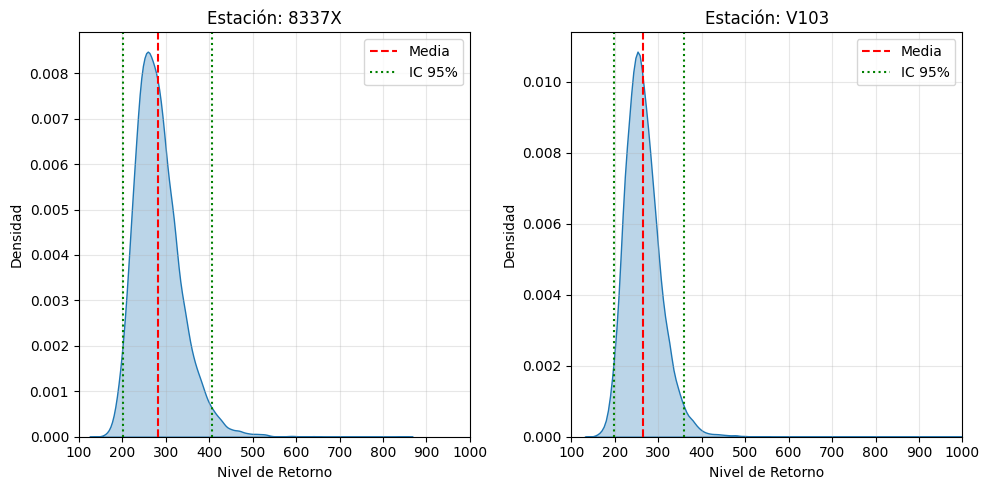

In [132]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

samples_df = fit_all.to_frame()
station_names = Station_filter_copy.columns.tolist()

# Define las estaciones que quieres graficar por nombre:
selected_station_names = ['8337X', 'V103']

# Encuentra las posiciones (índices) de esas estaciones:
selected_indices = [station_names.index(name) for name in selected_station_names]

# Reconstruir levels_100 para el periodo 4 (T=100 años)
n_stations = len(station_names)
levels_100 = np.stack(
    [samples_df[f'return_levels.{i+1}.4'].values for i in range(n_stations)],
    axis=1
)

# Configurar los subplots para el número de estaciones seleccionadas
n_selected = len(selected_indices)
n_rows = int(np.ceil(n_selected / 2))  # 2 columnas
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
axes = axes.flatten()

# Graficar solo las estaciones seleccionadas
for plot_idx, station_idx in enumerate(selected_indices):
    station = station_names[station_idx]
    station_mean = np.mean(levels_100[:, station_idx])
    station_ci = np.percentile(levels_100[:, station_idx], [2.5, 97.5])
    
    sns.kdeplot(data=levels_100[:, station_idx], ax=axes[plot_idx], fill=True, alpha=0.3)
    axes[plot_idx].axvline(station_mean, color='red', linestyle='--', label='Media')
    axes[plot_idx].axvline(station_ci[0], color='green', linestyle=':', label='IC 95%')
    axes[plot_idx].axvline(station_ci[1], color='green', linestyle=':')
    
    axes[plot_idx].set_title(f'Estación: {station}')
    axes[plot_idx].set_xlabel('Nivel de Retorno')
    axes[plot_idx].set_ylabel('Densidad')
    axes[plot_idx].set_xlim(100, 1000)
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].legend()

# Eliminar subplots vacíos si hay menos de 4 espacios en la cuadrícula
for i in range(n_selected, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

## 2.2. Sin evento **DANA**

In [133]:
# Filtrar los datos hasta 2023
Station_filter_nu = Station_filter.loc[:'2023', :]

# Ajustar modelo
fit_nu = fit_gev_hierarchical(Station_filter_nu)

# Extraer resultados como DataFrame
samples_ = fit_nu.to_frame()

# Imprimir parámetros poblacionales
print("\nParámetros poblacionales (media ± desv. std):")
print(f"μ población: {samples_['mu_pop'].mean():.2f} ± {samples_['mu_pop'].std():.2f}")
print(f"σ población: {samples_['sigma_pop'].mean():.2f} ± {samples_['sigma_pop'].std():.2f}")
print(f"ξ población: {samples_['xi_pop'].mean():.3f} ± {samples_['xi_pop'].std():.3f}")

# Extraer niveles de retorno T=100 años
n_stations = len(Station_filter_nu.columns)
levels_100 = np.stack(
    [samples_[f'return_levels.{i+1}.4'].values for i in range(n_stations)],
    axis=1
)

# Imprimir niveles de retorno para T=100 años
print("\nNiveles de retorno para T=100 años:")
for i, station in enumerate(Station_filter_nu.columns):
    mean = np.mean(levels_100[:, i])
    ci = np.percentile(levels_100[:, i], [2.5, 97.5])
    print(f"{station}: {mean:.1f} [{ci[0]:.1f}, {ci[1]:.1f}]")


Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 67, column 16: A
    control flow statement depends on parameter(s): mu_pop, mu_raw,
    sigma_pop, sigma_raw, tau_mu, tau_sigma, tau_xi, xi_pop, xi_raw.
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 65, column 12: A
    control flow statement depends on parameter(s): tau_xi, xi_pop, xi_raw.
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 51, column 26: Argument
    12 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
Warning in '/tmp/httpstan_m7ljgh0m/model_s2vfvinc.stan', line 50, column 23: Argument
    50 suggests there may be parameters that are not unit scale; consider
    rescaling with a multiplier (see manual section 22.12).
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(


Parámetros poblacionales (media ± desv. std):
μ población: 57.39 ± 1.10
σ población: 27.30 ± 0.70
ξ población: 0.150 ± 0.016

Niveles de retorno para T=100 años:
V05: 198.4 [148.1, 267.6]
V23: 307.9 [234.9, 409.0]
V01: 214.9 [160.3, 290.2]
V103: 236.0 [180.7, 309.8]
V10: 212.5 [160.8, 282.0]
CS08: 240.5 [181.7, 320.6]
CS101: 229.6 [172.7, 304.7]
CS01: 233.3 [177.6, 306.4]
V19: 247.1 [188.7, 326.2]
V20: 194.7 [148.0, 258.0]
V02: 174.2 [129.2, 234.7]
V104: 246.9 [189.3, 323.0]
A05: 294.0 [227.2, 385.4]
CS07: 224.3 [169.3, 297.8]
CS06: 238.9 [179.0, 319.3]
V22: 310.9 [239.7, 407.9]
c30m136e03: 479.6 [366.6, 637.7]
A101: 160.5 [118.3, 219.5]
CS03: 225.2 [174.4, 292.2]
A03: 155.4 [114.1, 212.2]
8050X: 271.2 [208.5, 354.5]
V102: 332.8 [254.5, 438.0]
CS09: 182.1 [136.7, 245.7]
V101: 203.3 [153.0, 271.4]
A08: 174.0 [127.7, 236.9]
CS05: 221.0 [166.1, 295.0]
c11m116e05: 184.3 [138.3, 248.8]
V07: 284.3 [216.3, 374.9]
A15: 240.8 [181.2, 320.8]
A04: 306.8 [239.3, 398.2]
V04: 238.5 [181.1, 315.6]
A

In [134]:
samples_df = fit_nu.to_frame()

mu_mean = samples_df['mu_station.1'].mean()
sigma_mean = samples_df['sigma_station.1'].mean()
xi_mean = samples_df['xi_station.1'].mean()

print(mu_mean, sigma_mean, xi_mean)



48.90040366784574 22.210443906539112 0.15453483353047467


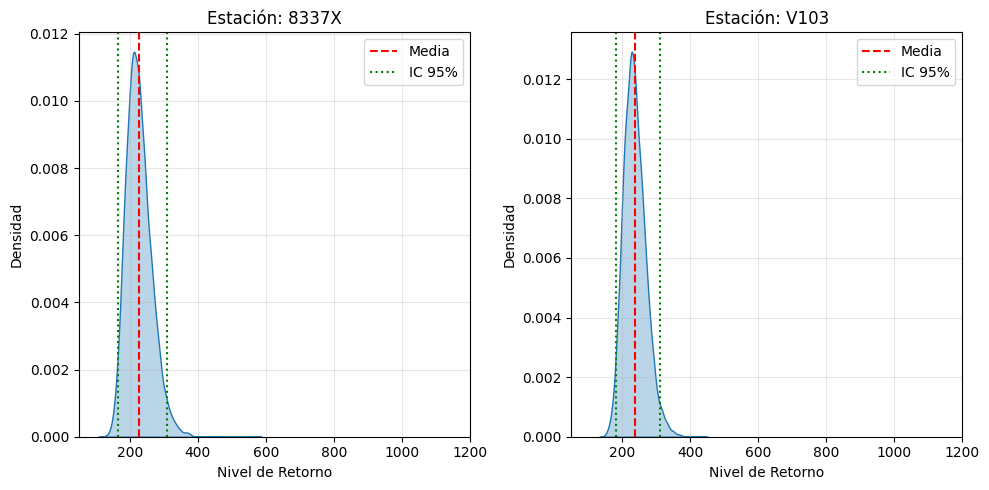

In [135]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer resultados como DataFrame
samples_df = fit_nu.to_frame()
station_names = Station_filter_copy.columns.tolist()

# Define las estaciones que quieres graficar por nombre:
selected_station_names = ['8337X', 'V103']

# Encuentra las posiciones (índices) de esas estaciones:
selected_indices = [station_names.index(name) for name in selected_station_names]

# Extraer los niveles de retorno de 100 años (periodo 4 en Stan)
n_stations = len(station_names)
levels_100 = np.stack(
    [samples_df[f'return_levels.{i+1}.4'].values for i in range(n_stations)],
    axis=1
)

# Configuración de los subplots para las estaciones seleccionadas
n_selected = len(selected_indices)
n_rows = int(np.ceil(n_selected / 2))  # 2 columnas
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
axes = axes.flatten()

# Graficar solo las estaciones seleccionadas
for plot_idx, station_idx in enumerate(selected_indices):
    station = station_names[station_idx]
    station_mean = np.mean(levels_100[:, station_idx])
    station_ci = np.percentile(levels_100[:, station_idx], [2.5, 97.5])

    sns.kdeplot(data=levels_100[:, station_idx], ax=axes[plot_idx], fill=True, alpha=0.3)
    axes[plot_idx].axvline(station_mean, color='red', linestyle='--', label='Media')
    axes[plot_idx].axvline(station_ci[0], color='green', linestyle=':', label='IC 95%')
    axes[plot_idx].axvline(station_ci[1], color='green', linestyle=':')

    axes[plot_idx].set_title(f'Estación: {station}')
    axes[plot_idx].set_xlabel('Nivel de Retorno')
    axes[plot_idx].set_ylabel('Densidad')
    axes[plot_idx].set_xlim(50, 1200)
    axes[plot_idx].grid(True, alpha=0.3)
    axes[plot_idx].legend()

# Eliminar subplots vacíos si hay menos de 4 espacios en la cuadrícula
for i in range(n_selected, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# 3. Análisis comparativo 

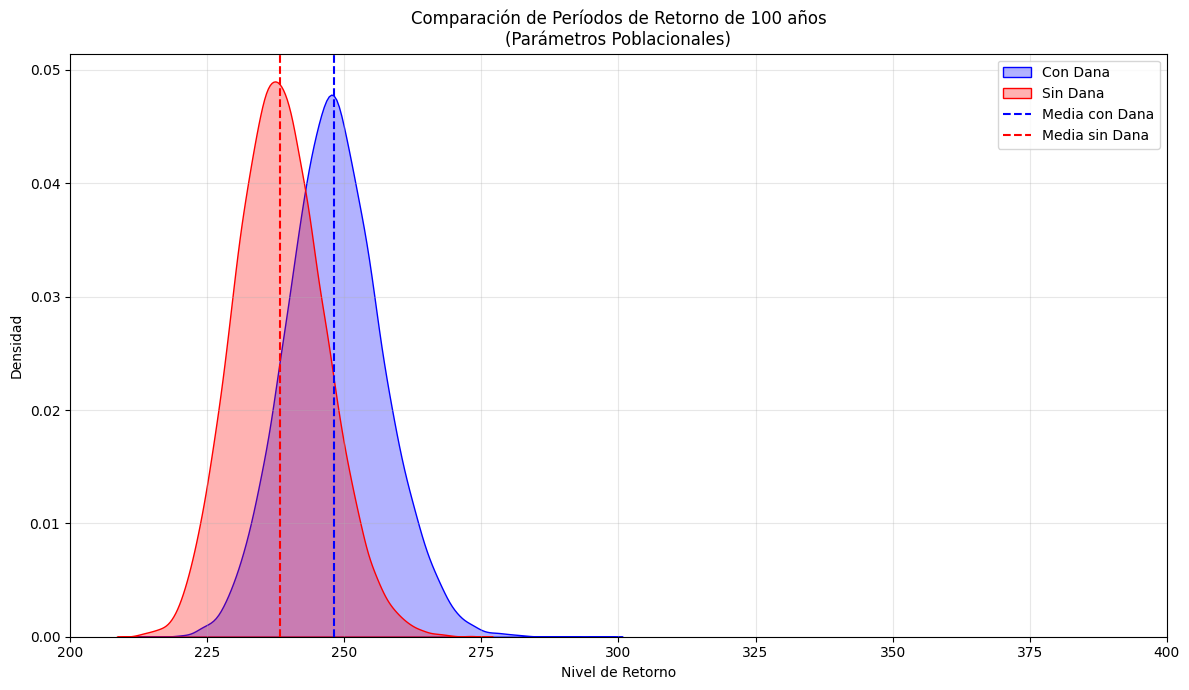

In [136]:
# Función para calcular el nivel de retorno de 100 años
def return_level_100(mu, sigma, xi):
    p = 1 - 1/100  # probabilidad para T=100
    if abs(xi) > 1e-6:
        return mu + (sigma/xi) * (np.power(-np.log(p), -xi) - 1)
    else:
        return mu - sigma * np.log(-np.log(p))

# Calcular niveles de retorno para el primer conjunto (samples)
mu_pop_samples1 = samples['mu_pop']
sigma_pop_samples1 = samples['sigma_pop']
xi_pop_samples1 = samples['xi_pop']

n_samples1 = len(mu_pop_samples1)
return_levels_100_1 = np.zeros(n_samples1)

for i in range(n_samples1):
    return_levels_100_1[i] = return_level_100(
        mu_pop_samples1[i], 
        sigma_pop_samples1[i], 
        xi_pop_samples1[i]
    )

# Calcular niveles de retorno para el segundo conjunto (samples_)
mu_pop_samples2 = samples_['mu_pop']
sigma_pop_samples2 = samples_['sigma_pop']
xi_pop_samples2 = samples_['xi_pop']

n_samples2 = len(mu_pop_samples2)
return_levels_100_2 = np.zeros(n_samples2)

for i in range(n_samples2):
    return_levels_100_2[i] = return_level_100(
        mu_pop_samples2[i], 
        sigma_pop_samples2[i], 
        xi_pop_samples2[i]
    )

# Crear el gráfico
plt.figure(figsize=(12, 7))

# Graficar KDE de los niveles de retorno para ambos conjuntos
sns.kdeplot(data=return_levels_100_1, color='blue', fill=True, alpha=0.3, label='Con Dana')
sns.kdeplot(data=return_levels_100_2, color='red', fill=True, alpha=0.3, label='Sin Dana')

# Añadir líneas verticales con las medias y CI para ambos modelos
mean_level1 = np.mean(return_levels_100_1)
ci_lower1, ci_upper1 = np.percentile(return_levels_100_1, [2.5, 97.5])

mean_level2 = np.mean(return_levels_100_2)
ci_lower2, ci_upper2 = np.percentile(return_levels_100_2, [2.5, 97.5])

# Líneas para Modelo 1
plt.axvline(mean_level1, color='blue', linestyle='--', label='Media con Dana')
#plt.axvline(ci_lower1, color='blue', linestyle=':', alpha=0.5)
#plt.axvline(ci_upper1, color='blue', linestyle=':', alpha=0.5)

# Líneas para Modelo 2
plt.axvline(mean_level2, color='red', linestyle='--', label='Media sin Dana')
plt.xlim(200, 400)
#plt.axvline(ci_lower2, color='red', linestyle=':', alpha=0.5)
#plt.axvline(ci_upper2, color='red', linestyle=':', alpha=0.5)

# Personalizar el gráfico
plt.title('Comparación de Períodos de Retorno de 100 años\n(Parámetros Poblacionales)')
plt.xlabel('Nivel de Retorno')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Comparación de parámetros poblacionales

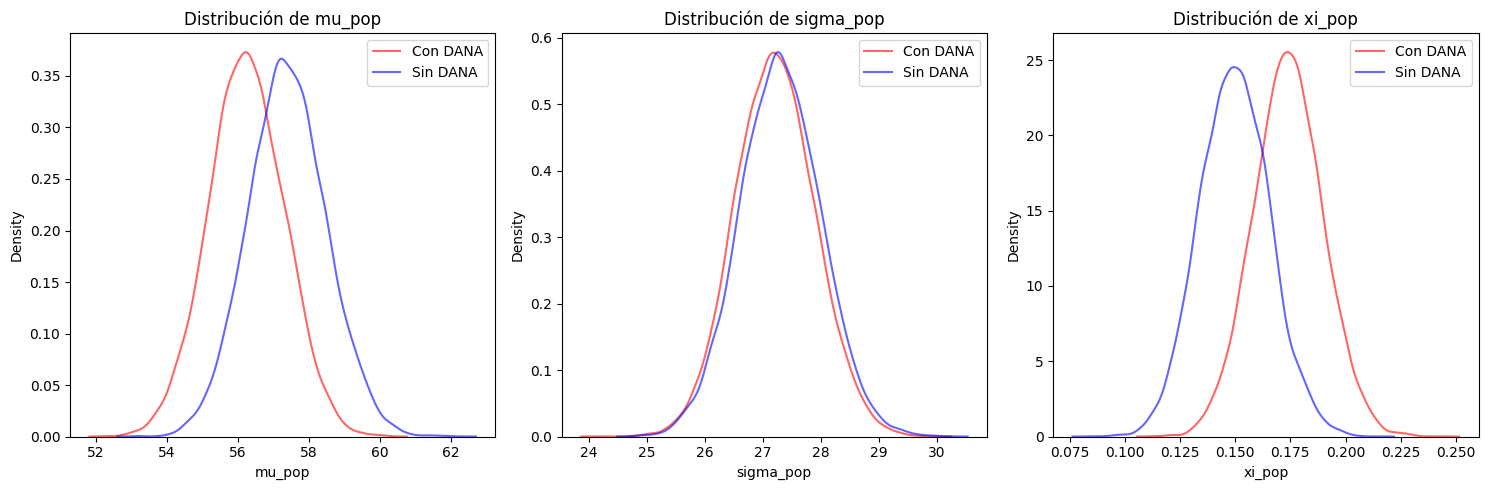

In [137]:
stations = Station_filter.columns  # O Station_filter_nu.columns
# Generar los gráficos
fig1 = plot_population_parameters_comparison(samples, samples_)


Comparación de niveles de retorno entre estaciones 

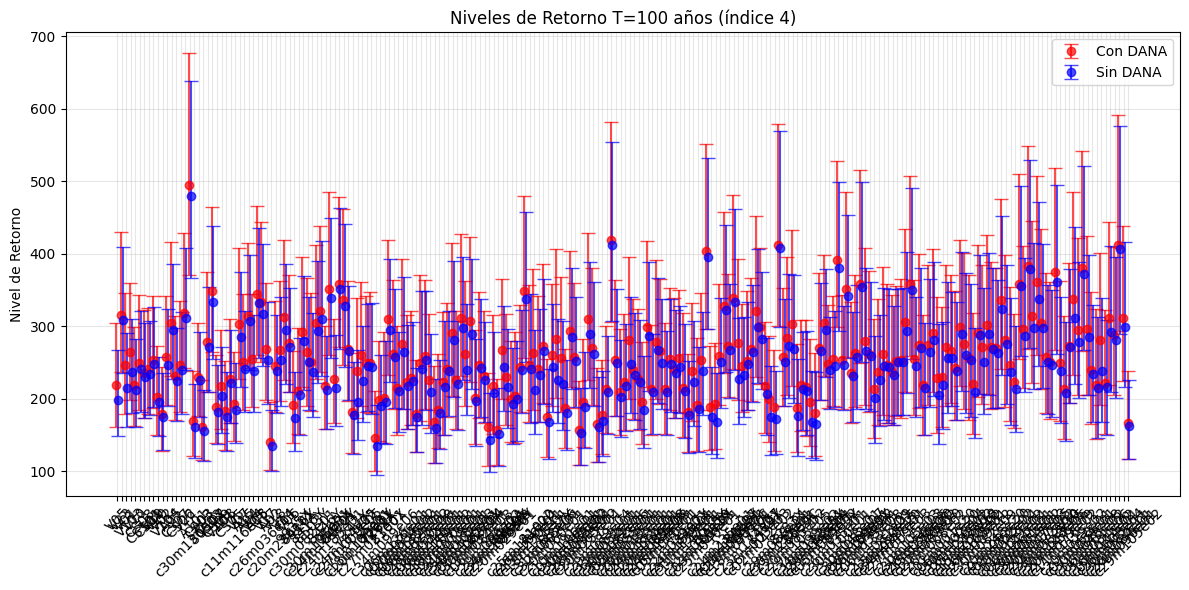

In [138]:
fig2 = plot_return_levels_comparison(samples, samples_, stations)


## Pruebas

In [139]:
from scipy.stats import genextreme

In [140]:
from scipy.stats import genextreme
import numpy as np

def fit_Parametric_gev(data):
    """
    Ajusta un modelo GEV paramétrico a cada estación usando scipy.stats.genextreme.
    
    Nota: scipy parametriza con shape = -ξ (diferente signo que Stan),
    por lo que aquí se invierte el signo del shape para mantener la compatibilidad
    con la parametrización de Stan.

    Parameters:
    -----------
    data : pd.DataFrame
        Cada columna es una estación, cada fila una observación (por ejemplo, máximos anuales).
    
    Returns:
    --------
    results : dict
        Diccionario con los parámetros ajustados por estación: shape, loc, scale.
    """
    results = {}
    
    for col in data.columns:
        station_data = data[col].dropna()
        
        # Comprobar que haya datos suficientes para ajustar
        if len(station_data) < 2:
            print(f"⚠️ Estación {col} tiene menos de 2 datos. Se omite el ajuste.")
            continue
        
        try:
            params = genextreme.fit(station_data)
            results[col] = {
                'shape': -params[0],  # Cambio de signo para compatibilidad con Stan
                'loc': params[1],
                'scale': params[2]
            }
        except Exception as e:
            print(f"❌ No se pudo ajustar GEV para la estación {col}: {e}")
    
    return results

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_gev_approaches(fit_all, fit_nu, station_names, data_all, data_nu):
    """
    Compara GEV regional (con/sin DANA) vs GEV paramétrico.
    Adaptada a pystan 3.x (httpstan), manteniendo el formato de impresión original.
    """

    # Convertir las muestras a DataFrame (pystan 3.x)
    samples_all = fit_all.to_frame()
    samples_nu = fit_nu.to_frame()

    # Ajustar GEV paramétrico
    Parametric_fits_all = fit_Parametric_gev(data_all)
    Parametric_fits_nu = fit_Parametric_gev(data_nu)

    # --------------------------
    # 1. Imprimir parámetros poblacionales globales
    # --------------------------
    print("\nParámetros Globales:")
    print("\nCon DANA:")
    print(f"μ población: {samples_all['mu_pop'].mean():.2f} ± {samples_all['mu_pop'].std():.2f}")
    print(f"σ población: {samples_all['sigma_pop'].mean():.2f} ± {samples_all['sigma_pop'].std():.2f}")
    print(f"ξ población: {samples_all['xi_pop'].mean():.3f} ± {samples_all['xi_pop'].std():.3f}")

    print("\nSin DANA:")
    print(f"μ población: {samples_nu['mu_pop'].mean():.2f} ± {samples_nu['mu_pop'].std():.2f}")
    print(f"σ población: {samples_nu['sigma_pop'].mean():.2f} ± {samples_nu['sigma_pop'].std():.2f}")
    print(f"ξ población: {samples_nu['xi_pop'].mean():.3f} ± {samples_nu['xi_pop'].std():.3f}")

    # --------------------------
    # 2. Preparar datos para el plot (Boxplots)
    # --------------------------
    plot_data = []
    params = {'mu': 'Localización (μ)', 'sigma': 'Escala (σ)', 'xi': 'Forma (ξ)'}

    for i, station in enumerate(station_names):
        for param_key, param_label in params.items():
            # Regional con DANA
            param_all = samples_all[f'{param_key}_station.{i+1}']
            for value in param_all:
                plot_data.append({'Estación': station, 'Parámetro': param_label, 'Valor': value, 'Modelo': 'Regional con DANA'})
            
            # Regional sin DANA
            param_nu = samples_nu[f'{param_key}_station.{i+1}']
            for value in param_nu:
                plot_data.append({'Estación': station, 'Parámetro': param_label, 'Valor': value, 'Modelo': 'Regional sin DANA'})

            # Parámetros globales (una vez)
            if i == 0:
                for value in samples_all[f'{param_key}_pop']:
                    plot_data.append({'Estación': 'Global', 'Parámetro': param_label, 'Valor': value, 'Modelo': 'Regional con DANA'})
                for value in samples_nu[f'{param_key}_pop']:
                    plot_data.append({'Estación': 'Global', 'Parámetro': param_label, 'Valor': value, 'Modelo': 'Regional sin DANA'})

    df = pd.DataFrame(plot_data)

    # --------------------------
    # 3. Crear Boxplots comparativos
    # --------------------------
    fig, axs = plt.subplots(3, 1, figsize=(15, 20))
    plt.subplots_adjust(hspace=0.3)

    colors = {'Regional con DANA': 'lightblue', 'Regional sin DANA': 'lightgreen',
              'Parametric con DANA': 'b', 'Parametric sin DANA': 'g'}
    param_map = {'Localización (μ)': 'loc', 'Escala (σ)': 'scale', 'Forma (ξ)': 'shape'}

    for idx, (param_key, param_label) in enumerate(params.items()):
        df_param = df[df['Parámetro'] == param_label]

        sns.boxplot(data=df_param, x='Estación', y='Valor', hue='Modelo', ax=axs[idx],
                    palette=[colors['Regional con DANA'], colors['Regional sin DANA']])
        axs[idx].get_legend().remove()  # Quitamos la leyenda individual

        # Líneas globales
        global_param_all = samples_all[f'{param_key}_pop'].mean()
        global_param_nu = samples_nu[f'{param_key}_pop'].mean()
        axs[idx].axhline(y=global_param_all, color=colors['Regional con DANA'], linestyle='--', alpha=0.8)
        axs[idx].axhline(y=global_param_nu, color=colors['Regional sin DANA'], linestyle='--', alpha=0.8)

        # Puntos paramétricos individuales
        for j, station in enumerate(station_names):
            if station != 'Global':
                indiv_value_all = Parametric_fits_all[station][param_map[param_label]]
                indiv_value_nu = Parametric_fits_nu[station][param_map[param_label]]
                axs[idx].scatter(j, indiv_value_all, color=colors['Parametric con DANA'], s=100, marker='*')
                axs[idx].scatter(j, indiv_value_nu, color=colors['Parametric sin DANA'], s=100, marker='o')

        axs[idx].set_title(f'Distribución de {param_label} por estación', pad=20)
        axs[idx].set_xlabel('Estación')
        axs[idx].set_ylabel(param_label)
        axs[idx].grid(True, alpha=0.3)
        axs[idx].tick_params(axis='x', rotation=45)

    # --------------------------
    # 4. LEYENDA ÚNICA DEBAJO DE LOS GRÁFICOS
    # --------------------------
    handles = [
        plt.Line2D([0], [0], color=colors['Regional con DANA'], linestyle='-', label='Regional con DANA'),
        plt.Line2D([0], [0], color=colors['Regional sin DANA'], linestyle='-', label='Regional sin DANA'),
        plt.Line2D([0], [0], marker='*', linestyle='', color='b', markerfacecolor=colors['Parametric con DANA'], markersize=10, label='Parametric con DANA'),
        plt.Line2D([0], [0], marker='o', linestyle='', color='g', markerfacecolor=colors['Parametric sin DANA'], markersize=10, label='Parametric sin DANA')
    ]
    fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), frameon=False)
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])

    # ---------------------------
    # 5. Impresión de estadísticas comparativas (formato original)
    # ---------------------------
    print("\nComparación de estimaciones por estación:")
    for station in station_names:
        if station != 'Global':
            i = list(station_names).index(station)
            print(f"\n{station}:")
            print("Regional con DANA (media ± std):")
            print(f"  μ: {samples_all[f'mu_station.{i+1}'].mean():.2f} ± {samples_all[f'mu_station.{i+1}'].std():.2f}")
            print(f"  σ: {samples_all[f'sigma_station.{i+1}'].mean():.2f} ± {samples_all[f'sigma_station.{i+1}'].std():.2f}")
            print(f"  ξ: {samples_all[f'xi_station.{i+1}'].mean():.3f} ± {samples_all[f'xi_station.{i+1}'].std():.3f}")

            print("Regional sin DANA (media ± std):")
            print(f"  μ: {samples_nu[f'mu_station.{i+1}'].mean():.2f} ± {samples_nu[f'mu_station.{i+1}'].std():.2f}")
            print(f"  σ: {samples_nu[f'sigma_station.{i+1}'].mean():.2f} ± {samples_nu[f'sigma_station.{i+1}'].std():.2f}")
            print(f"  ξ: {samples_nu[f'xi_station.{i+1}'].mean():.3f} ± {samples_nu[f'xi_station.{i+1}'].std():.3f}")

            print("Individual con DANA:")
            print(f"  μ: {Parametric_fits_all[station]['loc']:.2f}")
            print(f"  σ: {Parametric_fits_all[station]['scale']:.2f}")
            print(f"  ξ: {Parametric_fits_all[station]['shape']:.3f}")

            print("Individual sin DANA:")
            print(f"  μ: {Parametric_fits_nu[station]['loc']:.2f}")
            print(f"  σ: {Parametric_fits_nu[station]['scale']:.2f}")
            print(f"  ξ: {Parametric_fits_nu[station]['shape']:.3f}")

    return fig, df, Parametric_fits_all, Parametric_fits_nu



Parámetros Globales:

Con DANA:
μ población: 56.24 ± 1.07
σ población: 27.21 ± 0.69
ξ población: 0.174 ± 0.016

Sin DANA:
μ población: 57.39 ± 1.10
σ población: 27.30 ± 0.70
ξ población: 0.150 ± 0.016

Comparación de estimaciones por estación:

V05:
Regional con DANA (media ± std):
  μ: 49.82 ± 4.57
  σ: 23.34 ± 3.99
  ξ: 0.183 ± 0.045
Regional sin DANA (media ± std):
  μ: 48.90 ± 4.39
  σ: 22.21 ± 3.84
  ξ: 0.155 ± 0.034
Individual con DANA:
  μ: 45.52
  σ: 18.10
  ξ: 0.446
Individual sin DANA:
  μ: 44.56
  σ: 16.88
  ξ: 0.421

V23:
Regional con DANA (media ± std):
  μ: 66.42 ± 6.55
  σ: 34.35 ± 5.39
  ξ: 0.183 ± 0.044
Regional sin DANA (media ± std):
  μ: 67.25 ± 6.78
  σ: 35.71 ± 5.62
  ξ: 0.155 ± 0.035
Individual con DANA:
  μ: 70.30
  σ: 36.26
  ξ: 0.287
Individual sin DANA:
  μ: 70.99
  σ: 37.53
  ξ: 0.283

V01:
Regional con DANA (media ± std):
  μ: 49.93 ± 5.01
  σ: 26.27 ± 4.48
  ξ: 0.193 ± 0.046
Regional sin DANA (media ± std):
  μ: 48.86 ± 4.80
  σ: 24.47 ± 4.14
  ξ: 0.158 ±

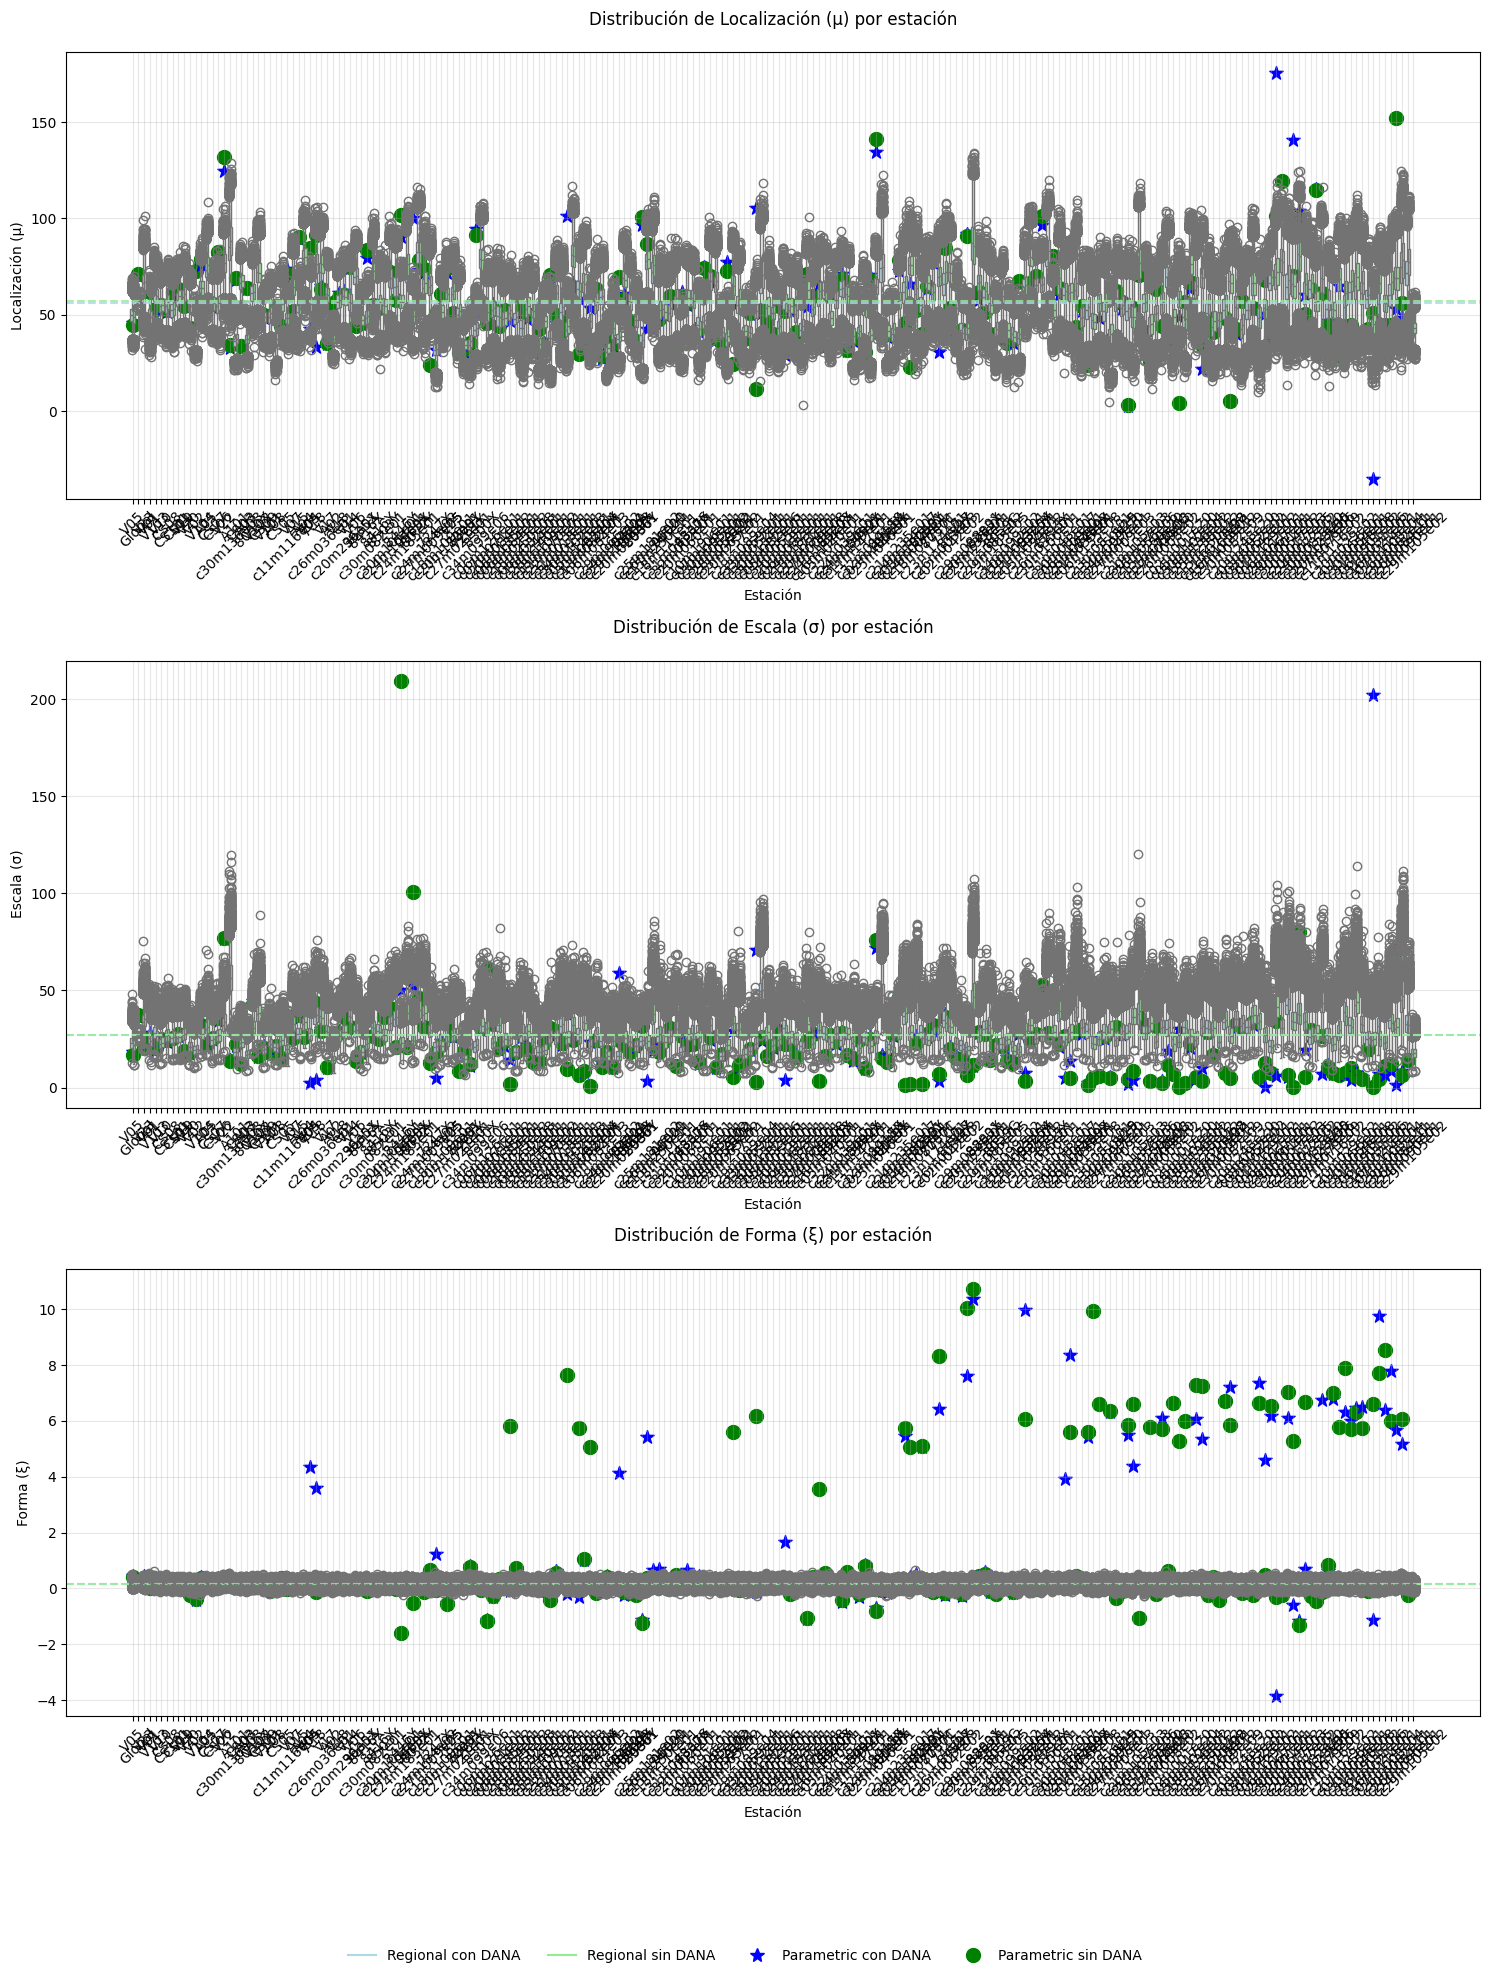

In [142]:
# Ejemplo de uso
if __name__ == "__main__":
    fig, df_comparison, individual_fits_all, individual_fits_nu = compare_gev_approaches(
        fit_all, fit_nu, Station_filter.columns, Station_filter, Station_filter_nu)

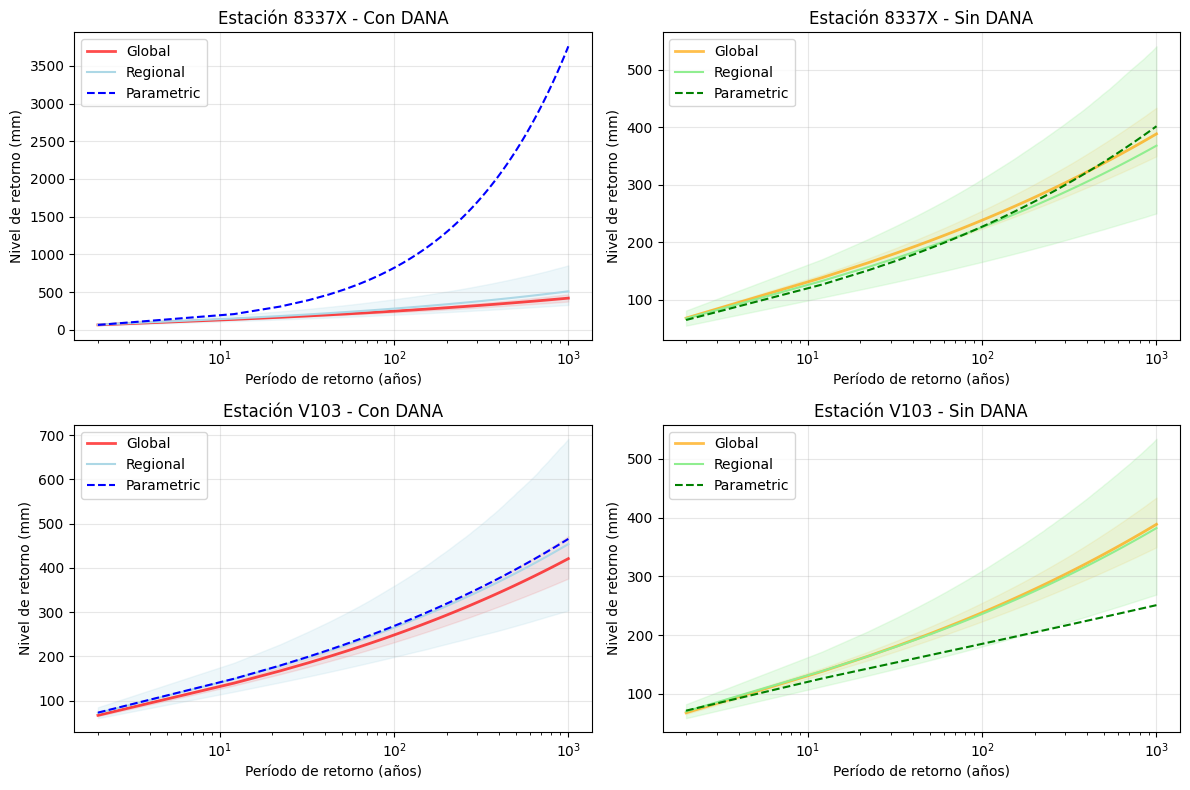

In [143]:
import numpy as np
import matplotlib.pyplot as plt

def plot_return_period_station_comparison(fit_all, fit_nu, individual_fits_all, individual_fits_nu, station_names, selected_station_names):
    """
    Genera plots lado a lado para estaciones seleccionadas, comparando niveles de retorno
    entre modelos Regional con/sin DANA, Global y Paramétrico.
    Compatible con pystan 3.x (usa .to_frame()).
    """
    samples_all = fit_all.to_frame()
    samples_nu = fit_nu.to_frame()
    station_names = list(station_names)

    # Obtener los índices de las estaciones seleccionadas
    selected_indices = [station_names.index(name) for name in selected_station_names]

    fig, axs = plt.subplots(len(selected_indices), 2, figsize=(12, 4 * len(selected_indices)))

    return_periods = np.linspace(2, 1000, 100)
    probs = 1 - 1 / return_periods

    colors = {
        'Regional con DANA': 'lightblue',
        'Regional sin DANA': 'lightgreen',
        'Parametric con DANA': 'blue',
        'Parametric sin DANA': 'green',
        'Global con DANA': 'red',
        'Global sin DANA': 'orange'
    }

    def gev_return_level(mu, sigma, xi, probs):
        """Calcula niveles de retorno GEV, considerando caso Gumbel."""
        return np.where(
            np.abs(xi) > 1e-6,
            mu + (sigma / xi) * (np.power(-np.log(probs), -xi) - 1),
            mu - sigma * np.log(-np.log(probs))
        )

    for plot_idx, idx in enumerate(selected_indices):
        station = station_names[idx]
        ax_dana = axs[plot_idx, 0]
        ax_no_dana = axs[plot_idx, 1]

        # GLOBAL CON DANA
        levels_global = np.array([
            gev_return_level(mu, sigma, xi, probs)
            for mu, sigma, xi in zip(samples_all['mu_pop'], samples_all['sigma_pop'], samples_all['xi_pop'])
        ])
        mean_levels_global = np.mean(levels_global, axis=0)
        ci_lower_global = np.percentile(levels_global, 2.5, axis=0)
        ci_upper_global = np.percentile(levels_global, 97.5, axis=0)
        ax_dana.plot(return_periods, mean_levels_global, '-', color=colors['Global con DANA'], label='Global', linewidth=2, alpha=0.7)
        ax_dana.fill_between(return_periods, ci_lower_global, ci_upper_global, color=colors['Global con DANA'], alpha=0.1)

        # REGIONAL CON DANA
        levels_bayes = np.array([
            gev_return_level(mu, sigma, xi, probs)
            for mu, sigma, xi in zip(samples_all[f'mu_station.{idx+1}'], samples_all[f'sigma_station.{idx+1}'], samples_all[f'xi_station.{idx+1}'])
        ])
        ax_dana.plot(return_periods, levels_bayes.mean(axis=0), '-', color=colors['Regional con DANA'], label='Regional')
        ax_dana.fill_between(return_periods, np.percentile(levels_bayes, 2.5, axis=0), np.percentile(levels_bayes, 97.5, axis=0), color=colors['Regional con DANA'], alpha=0.2)

        # PARAMÉTRICO CON DANA
        params = individual_fits_all[station]
        levels_param = gev_return_level(params['loc'], params['scale'], params['shape'], probs)
        ax_dana.plot(return_periods, levels_param, '--', color=colors['Parametric con DANA'], label='Parametric')

        # GLOBAL SIN DANA
        levels_global = np.array([
            gev_return_level(mu, sigma, xi, probs)
            for mu, sigma, xi in zip(samples_nu['mu_pop'], samples_nu['sigma_pop'], samples_nu['xi_pop'])
        ])
        mean_levels_global = np.mean(levels_global, axis=0)
        ci_lower_global = np.percentile(levels_global, 2.5, axis=0)
        ci_upper_global = np.percentile(levels_global, 97.5, axis=0)
        ax_no_dana.plot(return_periods, mean_levels_global, '-', color=colors['Global sin DANA'], label='Global', linewidth=2, alpha=0.7)
        ax_no_dana.fill_between(return_periods, ci_lower_global, ci_upper_global, color=colors['Global sin DANA'], alpha=0.1)

        # REGIONAL SIN DANA
        levels_bayes = np.array([
            gev_return_level(mu, sigma, xi, probs)
            for mu, sigma, xi in zip(samples_nu[f'mu_station.{idx+1}'], samples_nu[f'sigma_station.{idx+1}'], samples_nu[f'xi_station.{idx+1}'])
        ])
        ax_no_dana.plot(return_periods, levels_bayes.mean(axis=0), '-', color=colors['Regional sin DANA'], label='Regional')
        ax_no_dana.fill_between(return_periods, np.percentile(levels_bayes, 2.5, axis=0), np.percentile(levels_bayes, 97.5, axis=0), color=colors['Regional sin DANA'], alpha=0.2)

        # PARAMÉTRICO SIN DANA
        params = individual_fits_nu[station]
        levels_param = gev_return_level(params['loc'], params['scale'], params['shape'], probs)
        ax_no_dana.plot(return_periods, levels_param, '--', color=colors['Parametric sin DANA'], label='Parametric')

        # Personalización
        for ax, title in [(ax_dana, f'Estación {station} - Con DANA'), (ax_no_dana, f'Estación {station} - Sin DANA')]:
            ax.set_xscale('log')
            ax.set_xlabel('Período de retorno (años)')
            ax.set_ylabel('Nivel de retorno (mm)')
            ax.set_title(title)
            ax.grid(True, alpha=0.3)
            ax.legend()

    plt.tight_layout()
    return fig

# Ejemplo de uso
if __name__ == "__main__":
    fig = plot_return_period_station_comparison(
        fit_all, fit_nu, individual_fits_all, individual_fits_nu,
        Station_filter.columns,
        selected_station_names=['8337X', 'V103']
    )
    plt.show()

In [144]:
import pandas as pd
import numpy as np

def generate_return_period_table(fit_all, fit_nu, individual_fits_all, individual_fits_nu, station_names, selected_station_names, return_periods=[10, 100, 500]):
    """
    Generates a comparative table of return levels for different methods and stations.
    
    Args:
        fit_all, fit_nu: Model fit objects with/without DANA
        individual_fits_all, individual_fits_nu: Individual parametric fits
        station_names: List of station names
        selected_station_names: Stations to include in the table
        return_periods: List of return periods to evaluate
        
    Returns:
        DataFrame with the comparative results.
    """
    samples_all = fit_all.to_frame()
    samples_nu = fit_nu.to_frame()
    station_names = list(station_names)
    
    # Get indices of the selected stations
    selected_indices = [station_names.index(name) for name in selected_station_names]
    
    # Function to calculate GEV return levels
    def gev_return_level(mu, sigma, xi, T):
        p = 1 - 1 / T
        return np.where(
            np.abs(xi) > 1e-6,
            mu + (sigma / xi) * (np.power(-np.log(p), -xi) - 1),
            mu - sigma * np.log(-np.log(p))
        )
    
    results = []
    
    for idx, station in zip(selected_indices, selected_station_names):
        for T in return_periods:
            # WITH DANA
            # Regional
            levels_regional = np.array([
                gev_return_level(mu, sigma, xi, T)
                for mu, sigma, xi in zip(samples_all[f'mu_station.{idx+1}'], 
                                         samples_all[f'sigma_station.{idx+1}'], 
                                         samples_all[f'xi_station.{idx+1}'])
            ])
            reg_median = np.median(levels_regional)
            reg_p2_5 = np.percentile(levels_regional, 2.5)
            reg_p97_5 = np.percentile(levels_regional, 97.5)
            
            # Global
            levels_global = np.array([
                gev_return_level(mu, sigma, xi, T)
                for mu, sigma, xi in zip(samples_all['mu_pop'], 
                                         samples_all['sigma_pop'], 
                                         samples_all['xi_pop'])
            ])
            glob_median = np.median(levels_global)
            glob_p2_5 = np.percentile(levels_global, 2.5)
            glob_p97_5 = np.percentile(levels_global, 97.5)
            
            # Parametric
            params = individual_fits_all[station]
            param_value = gev_return_level(params['loc'], params['scale'], params['shape'], T)
            
            results.append({
                'Station': station,
                'Return Period': T,
                'DANA': 'With DANA',
                'Method': 'Regional',
                'Median': reg_median,
                'Percentile 2.5': reg_p2_5,
                'Percentile 97.5': reg_p97_5
            })
            
            results.append({
                'Station': station,
                'Return Period': T,
                'DANA': 'With DANA',
                'Method': 'Global',
                'Median': glob_median,
                'Percentile 2.5': glob_p2_5,
                'Percentile 97.5': glob_p97_5
            })
            
            
            # WITHOUT DANA
            # Regional
            levels_regional = np.array([
                gev_return_level(mu, sigma, xi, T)
                for mu, sigma, xi in zip(samples_nu[f'mu_station.{idx+1}'], 
                                         samples_nu[f'sigma_station.{idx+1}'], 
                                         samples_nu[f'xi_station.{idx+1}'])
            ])
            reg_median = np.median(levels_regional)
            reg_p2_5 = np.percentile(levels_regional, 2.5)
            reg_p97_5 = np.percentile(levels_regional, 97.5)
            
            # Global
            levels_global = np.array([
                gev_return_level(mu, sigma, xi, T)
                for mu, sigma, xi in zip(samples_nu['mu_pop'], 
                                         samples_nu['sigma_pop'], 
                                         samples_nu['xi_pop'])
            ])
            glob_median = np.median(levels_global)
            glob_p2_5 = np.percentile(levels_global, 2.5)
            glob_p97_5 = np.percentile(levels_global, 97.5)
            
            # Parametric
            params = individual_fits_nu[station]
            param_value = gev_return_level(params['loc'], params['scale'], params['shape'], T)
            
            results.append({
                'Station': station,
                'Return Period': T,
                'DANA': 'Without DANA',
                'Method': 'Regional',
                'Median': reg_median,
                'Percentile 2.5': reg_p2_5,
                'Percentile 97.5': reg_p97_5
            })
            
            results.append({
                'Station': station,
                'Return Period': T,
                'DANA': 'Without DANA',
                'Method': 'Global',
                'Median': glob_median,
                'Percentile 2.5': glob_p2_5,
                'Percentile 97.5': glob_p97_5
            })
            
    
    # Create DataFrame and format
    df = pd.DataFrame(results)
    df = df.round(2)
    
    # Reorder columns
    df = df[['Station', 'Return Period', 'DANA', 'Method', 'Median', 'Percentile 2.5', 'Percentile 97.5']]
    
    return df

# Example of use
if __name__ == "__main__":
    result_table = generate_return_period_table(
        fit_all, fit_nu, individual_fits_all, individual_fits_nu,
        Station_filter.columns,
        selected_station_names=['8337X', 'V103']
    )
    
    # Display formatted table
    from tabulate import tabulate
    print(tabulate(result_table, headers='keys', tablefmt='pretty', showindex=False))
    
    # Save to CSV
    result_table.to_csv('./Resultados_RP/resultados_jerarquico_regional_grande.csv', index=False)


+---------+---------------+--------------+----------+--------+----------------+-----------------+
| Station | Return Period |     DANA     |  Method  | Median | Percentile 2.5 | Percentile 97.5 |
+---------+---------------+--------------+----------+--------+----------------+-----------------+
|  8337X  |      10       |  With DANA   | Regional | 139.75 |     109.73     |      183.3      |
|  8337X  |      10       |  With DANA   |  Global  | 131.19 |     126.39     |     136.13      |
|  8337X  |      10       | Without DANA | Regional | 123.86 |     98.59      |     160.28      |
|  8337X  |      10       | Without DANA |  Global  | 130.43 |     125.79     |     135.32      |
|  8337X  |      100      |  With DANA   | Regional | 274.61 |     200.7      |     405.67      |
|  8337X  |      100      |  With DANA   |  Global  | 247.95 |     231.71     |      266.1      |
|  8337X  |      100      | Without DANA | Regional | 221.89 |     165.67     |     310.21      |
|  8337X  |      100